# Reto: Propensión de conversión de clientes (versión explicada)
Este notebook está comentado **línea por línea**. Cada bloque de código va precedido de una explicación de *qué hace* y *por qué*.

**¿Qué queremos lograr?** Para cada cliente de diciembre 2026 calcular un número entre 0 y 1: su **probabilidad de convertir** (contratar un producto por primera vez) en ese mes.

**¿Cómo nos califican?** Con el **Gini = 2·AUC − 1**. Solo importa que los clientes que sí convierten queden **arriba en el ranking**; no importa si la probabilidad es exactamente 0,13 o 0,14.

**Idea general del proceso:**
1. Cargar los datos.
2. Entenderlos (EDA).
3. Detectar trampas (una variable que cambia con el tiempo).
4. Crear variables nuevas.
5. Simular la competencia con el pasado (validación temporal).
6. Comparar modelos.
7. Combinar modelos.
8. Interpretar.
9. Entrenar el modelo final y crear el archivo de entrega.
10. **Entender qué significan las probabilidades** (sección nueva).

## 1. Configuración y carga de datos
### 1.1 Instalar librerías
Colab ya trae casi todo, pero `catboost` no viene instalado. El signo `!` le dice a Colab que ejecute un comando de terminal, no de Python.

In [1]:
!pip install -q lightgbm catboost   # instala LightGBM y CatBoost; -q = modo silencioso (no imprime todo el log)

### 1.2 Importar librerías
Una librería es un paquete de código ya escrito por otros. Aquí traemos las herramientas que usaremos.

In [2]:
import os, time, warnings          # os: manejar rutas de archivos | time: medir cuánto tarda cada modelo | warnings: silenciar avisos
import numpy as np                  # numpy: cálculos numéricos con arreglos (vectores, matrices)
import pandas as pd                 # pandas: tablas de datos (DataFrames), como un Excel dentro de Python
import matplotlib.pyplot as plt     # matplotlib: hacer gráficos
import lightgbm as lgb              # LightGBM: modelo de gradient boosting (árboles), el mejor en nuestras pruebas
from catboost import CatBoostClassifier                       # CatBoost: otro modelo de boosting, maneja bien las variables categóricas
from sklearn.metrics import roc_auc_score                     # función que calcula el AUC (de ahí sacamos el Gini)
from sklearn.linear_model import LogisticRegression           # regresión logística: nuestro modelo base, el más simple
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # OneHot: convierte categorías en columnas 0/1 | Scaler: estandariza números (media 0, desv. 1)
from sklearn.compose import ColumnTransformer                 # aplica una transformación distinta a cada grupo de columnas
from sklearn.pipeline import make_pipeline                    # encadena pasos: primero transformar, luego entrenar
from sklearn.model_selection import cross_val_predict, GroupKFold  # herramientas de validación cruzada (las usamos en la validación adversarial)
from scipy.stats import rankdata                              # convierte números en posiciones de ranking (1°, 2°, 3°...)

warnings.filterwarnings('ignore')            # oculta avisos que no son errores, para que la salida se vea limpia
pd.set_option('display.max_columns', 50)     # muestra hasta 50 columnas al imprimir una tabla
SEED = 42                                    # 'semilla' aleatoria: hace que los resultados salgan iguales cada vez que se ejecuta

### 1.3 Cargar los archivos
Si los CSV no están en la carpeta, Colab abre una ventana para que los subas.

In [3]:
DATA_DIR = os.environ.get('DATA_DIR', '.')   # carpeta donde buscar los CSV; '.' = carpeta actual
necesarios = ['train.csv', 'test.csv', 'sample_submission.csv']   # lista de archivos obligatorios

# all(...) es True solo si TODOS los archivos existen; si falta alguno entramos al if
if not all(os.path.exists(os.path.join(DATA_DIR, f)) for f in necesarios):
    try:
        from google.colab import files          # herramienta de Colab para subir y descargar archivos
        print('Sube train.csv, test.csv, sample_submission.csv y metaData.csv')
        files.upload()                          # abre la ventana para elegir archivos de tu computadora
        DATA_DIR = '.'                          # los archivos subidos quedan en la carpeta actual
    except ImportError:                         # si no estamos en Colab (por ejemplo en Jupyter local)
        raise FileNotFoundError('Coloca los CSV en la carpeta de trabajo o define DATA_DIR')

train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))              # 110.100 filas: enero a noviembre, CON la respuesta (objetivo)
test  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))               # 9.900 filas: diciembre, SIN la respuesta (eso es lo que predecimos)
sub   = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))  # ejemplo del formato de entrega

print('train', train.shape, '| test', test.shape, '| submission', sub.shape)   # .shape = (filas, columnas)
print('Valores faltantes en train:', train.isna().sum().sum(), '| en test:', test.isna().sum().sum())  # cuenta celdas vacías
train.head()   # muestra las primeras 5 filas para ver cómo son los datos

train (110100, 25) | test (9900, 24) | submission (9900, 2)
Valores faltantes en train: 0 | en test: 0


,id_cliente,mes,edad,ingresos,ratio_deuda_ingresos,antiguedad_cuenta_meses,numero_productos,saldo_promedio,dias_ultima_transaccion,ocupacion,region,canal_adquisicion,banda_riesgo,tiene_tarjeta_credito,activo_movil,es_nuevo_cliente,tiene_prestamo,antiguedad_direccion_meses,visitas_web_ultimos_90_dias,distancia_sucursal_km,dispositivo_principal,dia_preferido_pago,tiene_seguro,dias_ultima_interaccion,objetivo
0,1,202601,26,42120.349663,0.367310,139,2,40949.765573,67,professional,west,web,low,False,True,False,False,222,10,9.898223,android,21,True,67,0
1,2,202601,56,89837.390440,0.338092,29,2,35233.622561,304,manager,west,web,low,False,True,False,False,58,2,9.311922,ios,20,True,304,0
2,3,202601,34,45951.715455,0.444587,21,2,39486.902998,220,clerical,north,web,high,True,True,False,False,8,6,12.188249,android,12,False,220,0
3,4,202601,62,54673.148516,0.243261,43,2,300.000000,110,manual,north,partner,high,False,False,False,False,119,9,10.459796,ios,20,False,110,0
4,5,202601,37,100239.135609,0.230946,113,1,32066.808006,247,professional,north,partner,medium,True,True,False,False,25,6,36.502645,ios,13,False,247,1


## 2. Análisis exploratorio (EDA)
Antes de modelar hay que **entender** los datos: cuánto convierte, si cambia por mes y qué variables importan.

### 2.1 Tasa de conversión por mes
La *tasa de conversión* es el promedio de `objetivo` (como es 0 o 1, el promedio = proporción de 1s).

Tasa global de conversión: 0.1505


,filas,tasa
mes,,
202601,10400,0.146
202602,9800,0.157
202603,10300,0.148
202604,9600,0.153
202605,10100,0.157
202606,10350,0.155
202607,9700,0.145
202608,10050,0.144
202609,9900,0.141


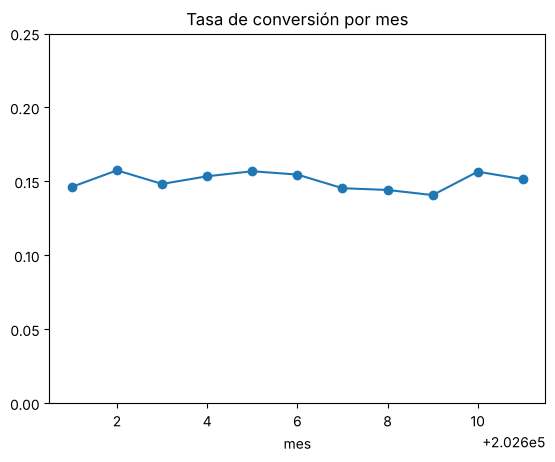

In [4]:
# groupby('mes'): agrupa las filas por mes | agg: calcula para cada grupo el número de filas y la tasa (promedio de objetivo)
tasa_mes = train.groupby('mes')['objetivo'].agg(filas='size', tasa='mean')
print('Tasa global de conversión:', round(train.objetivo.mean(), 4))   # ~0.15 = 15% de las filas convierten
display(tasa_mes.round(3))                                             # muestra la tabla redondeada a 3 decimales
tasa_mes['tasa'].plot(marker='o', title='Tasa de conversión por mes', ylim=(0, 0.25))  # gráfico de línea
plt.show()                                                             # dibuja el gráfico

**Cómo leerlo:** si la línea es plana (≈15% todos los meses), no hay estacionalidad fuerte: diciembre debería comportarse parecido.

### 2.2 Estructura de panel
Un mismo cliente aparece varios meses. Según el metaData, **cuando convierte deja de aparecer**. Es como un estudio de supervivencia: cada mes vemos solo a los que todavía no han convertido.

In [5]:
print('Clientes únicos en train:', train.id_cliente.nunique())   # nunique = cuántos valores distintos hay
# isin: ¿el id de test aparece en train? .mean() da la proporción de True
print('Clientes de test que ya estaban en train:', round(test.id_cliente.isin(train.id_cliente).mean(), 3))
# suma de objetivo por cliente; si alguno tuviera >1 significaría que convirtió dos veces (no debería pasar)
print('Clientes con más de una conversión:', (train.groupby('id_cliente').objetivo.sum() > 1).sum())

# ¿Las variables cambian dentro de un mismo cliente a lo largo de los meses?
num_cols = train.select_dtypes('number').columns.drop(['id_cliente', 'mes', 'objetivo'])  # columnas numéricas, sin ids ni la respuesta
print('\nPromedio de valores distintos por cliente (1 = la variable no cambia):')
# para cada cliente cuenta cuántos valores distintos tiene cada variable, y luego promedia entre clientes
print(train.groupby('id_cliente')[list(num_cols)].nunique().mean().round(2))

Clientes únicos en train: 24628
Clientes de test que ya estaban en train: 0.814
Clientes con más de una conversión: 0

Promedio de valores distintos por cliente (1 = la variable no cambia):


edad                           1.00
ingresos                       1.00
ratio_deuda_ingresos           1.00
antiguedad_cuenta_meses        1.00
numero_productos               1.00
saldo_promedio                 1.00
dias_ultima_transaccion        1.00
antiguedad_direccion_meses     1.00
visitas_web_ultimos_90_dias    1.00
distancia_sucursal_km          1.00
dia_preferido_pago             1.00
dias_ultima_interaccion        2.82
dtype: float64


**Conclusión:** casi todas las variables valen siempre lo mismo para un cliente (promedio = 1). Solo `dias_ultima_interaccion` cambia, y eso es sospechoso (sección 3).

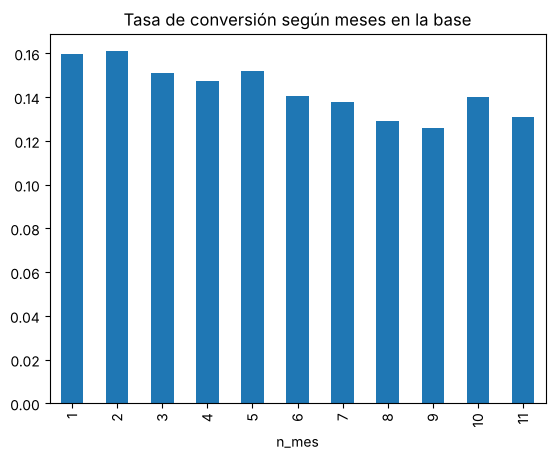

In [6]:
tmp = train.sort_values('mes').copy()                       # copia de train ordenada por mes
tmp['n_mes'] = tmp.groupby('id_cliente').cumcount() + 1     # cumcount numera las apariciones de cada cliente: 0,1,2... (+1 → 1,2,3...)
# tasa de conversión según cuántos meses lleva el cliente en la base
tmp.groupby('n_mes')['objetivo'].mean().plot(kind='bar', title='Tasa de conversión según meses en la base')
plt.show()

**Cómo leerlo:** los clientes en su primer mes convierten más (~16%) que los que llevan muchos meses (~13%). Los más interesados convierten rápido; los que quedan son más difíciles.

### 2.3 Poder predictivo de cada variable por separado
Calculamos el Gini usando **solo una variable** como si fuera la predicción. Un Gini cercano a 0 = la variable no ordena; lejos de 0 = sí ordena. Si es negativo, ordena al revés (a mayor valor, menor conversión).

In [7]:
gini = lambda y, p: 2 * roc_auc_score(y, p) - 1     # definimos nuestra métrica: y = respuestas reales, p = puntajes
# para cada variable numérica calculamos su Gini, y ordenamos por valor absoluto (de mayor a menor importancia)
g_uni = pd.Series({c: gini(train.objetivo, train[c]) for c in num_cols}).sort_values(key=abs, ascending=False)
display(g_uni.round(3).to_frame('gini_univariado'))

cats  = ['ocupacion', 'region', 'canal_adquisicion', 'banda_riesgo', 'dispositivo_principal']   # variables de texto (categorías)
bools = ['tiene_tarjeta_credito', 'activo_movil', 'es_nuevo_cliente', 'tiene_prestamo', 'tiene_seguro']  # variables Sí/No
for c in cats + bools:     # para cada una: cuántas filas hay por categoría y su tasa de conversión
    print(train.groupby(c)['objetivo'].agg(filas='size', tasa='mean').round(3), '\n')

,gini_univariado
numero_productos,0.114
dias_ultima_transaccion,-0.093
dias_ultima_interaccion,-0.058
antiguedad_cuenta_meses,0.017
ratio_deuda_ingresos,-0.017
saldo_promedio,0.013
edad,0.011
ingresos,0.009
visitas_web_ultimos_90_dias,-0.004
distancia_sucursal_km,0.003


               filas   tasa
ocupacion                  
clerical       33037  0.152
manager        11375  0.141
manual         30650  0.149
professional   24952  0.153
self_employed  10086  0.153 

         filas   tasa
region               
central  16655  0.146
east     19516  0.155
north    24088  0.150
south    22245  0.151
west     27596  0.150 

                   filas   tasa
canal_adquisicion              
branch             17103  0.141
call_center        16096  0.156
mobile             29068  0.151
partner            11430  0.145
web                36403  0.153 

              filas   tasa
banda_riesgo              
high          23142  0.087
low           51495  0.186
medium        35463  0.140 

                       filas   tasa
dispositivo_principal              
android                46241  0.151
ios                    35007  0.151
otro                    6442  0.145
web                    22410  0.150 

                       filas   tasa
tiene_tarjeta_credito        

**Cómo leerlo:** por ejemplo, `banda_riesgo = low` convierte ~18,6% y `high` ~8,7%: el riesgo es una variable muy útil. En cambio, si todas las regiones tienen ~15%, la región no ayuda.

## 3. Hallazgo clave: drift en `dias_ultima_interaccion`
*Drift* = una variable cambia su comportamiento con el tiempo. Si el modelo aprende un patrón de enero que no existe en diciembre, se equivoca.

,% filas con interaccion == transaccion
mes,
202601,1.000
202602,0.909
202603,0.819
202604,0.728
202605,0.637
202606,0.547
202607,0.457
202608,0.365
202609,0.276


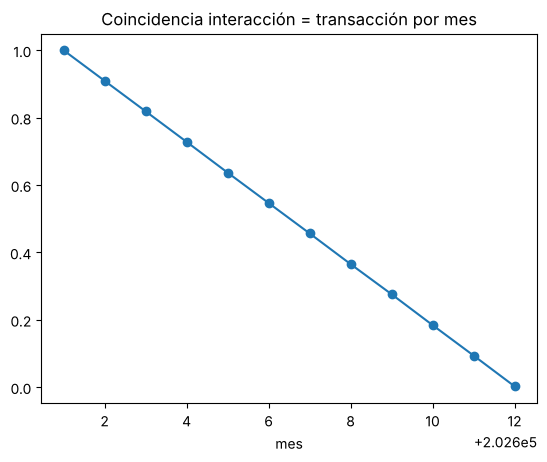

In [8]:
# función que devuelve True en las filas donde interacción y transacción son iguales
iguales = lambda d: (d.dias_ultima_interaccion == d.dias_ultima_transaccion)
comp = train.assign(igual=iguales(train)).groupby('mes')['igual'].mean()   # % de filas iguales por mes en train
comp.loc[202612] = iguales(test).mean()                                    # agregamos diciembre (test)
display(comp.round(3).to_frame('% filas con interaccion == transaccion'))
comp.plot(marker='o', title='Coincidencia interacción = transacción por mes')
plt.show()

**Cómo leerlo:** en enero coinciden el 100% de las filas, en noviembre el 9% y en diciembre el 0,3%. La variable 'se mueve' con el tiempo: es peligrosa.

### Validación adversarial
Entrenamos un modelo cuyo trabajo es adivinar si una fila es de **train** o de **test**.
- AUC ≈ 0,5 → no puede distinguirlas → train y test se parecen (bien).
- AUC alto → alguna variable delata el periodo (mal).

Usamos `GroupKFold` por cliente: el mismo cliente aparece en train y test con datos casi iguales, y si lo partiéramos al azar el resultado sería engañoso.

In [9]:
# unimos train (marcado es_test=0) y test (es_test=1) en una sola tabla
adv = pd.concat([train.drop(columns='objetivo').assign(es_test=0), test.assign(es_test=1)], ignore_index=True)
for c in cats: adv[c] = adv[c].astype('category')   # LightGBM necesita que el texto sea tipo 'category'
for c in bools: adv[c] = adv[c].astype(int)         # True/False → 1/0
adv['coincide_interaccion'] = iguales(adv).astype(int)   # variable auxiliar: 1 si interacción == transacción
base_feats = [c for c in test.columns if c not in ['id_cliente', 'mes']]   # todas las variables predictoras
escenarios = [('con dias_ultima_interaccion', base_feats + ['coincide_interaccion']),
              ('sin dias_ultima_interaccion', [f for f in base_feats if f != 'dias_ultima_interaccion'])]
for nombre, F in escenarios:
    # cross_val_predict: entrena en 4/5 de los clientes y predice el 1/5 restante, 5 veces
    p = cross_val_predict(lgb.LGBMClassifier(n_estimators=200, verbose=-1, random_state=SEED),
                          adv[F], adv.es_test, cv=GroupKFold(5), groups=adv.id_cliente,
                          method='predict_proba')[:, 1]          # [:,1] = probabilidad de ser test
    print(f'AUC adversarial {nombre}: {roc_auc_score(adv.es_test, p):.3f}')

AUC adversarial con dias_ultima_interaccion: 0.771


AUC adversarial sin dias_ultima_interaccion: 0.519


**Resultado:** con la variable AUC ≈ 0,77 (delata el periodo); sin ella ≈ 0,52 (train y test se parecen). **Decisión: la eliminamos.**

## 4. Ingeniería de variables
Creamos variables nuevas con sentido económico:
| Variable | Fórmula | Idea |
|---|---|---|
| `n_mes` | nº de mes en que aparece el cliente | efecto de supervivencia |
| `deuda` | ratio deuda/ingresos × ingresos | deuda en dinero, no en proporción |
| `saldo_ingresos` | saldo / ingresos | colchón de liquidez |
| `prod_por_anio` | productos / años de antigüedad | qué tan rápido se vincula con el banco |

In [10]:
df = pd.concat([train, test], ignore_index=True)        # unimos train y test para crear las variables igual en ambos
df['n_mes'] = df.sort_values('mes').groupby('id_cliente').cumcount() + 1   # 1 = primer mes del cliente en la base, 2 = segundo...
df['deuda'] = df.ratio_deuda_ingresos * df.ingresos            # deuda absoluta
df['saldo_ingresos'] = df.saldo_promedio / df.ingresos         # saldo relativo a ingresos
df['prod_por_anio'] = df.numero_productos / (df.antiguedad_cuenta_meses / 12 + 1)   # +1 evita dividir entre 0
for c in bools: df[c] = df[c].astype(int)                      # True/False → 1/0

nums = ['edad', 'ingresos', 'ratio_deuda_ingresos', 'antiguedad_cuenta_meses', 'numero_productos',
        'saldo_promedio', 'dias_ultima_transaccion', 'antiguedad_direccion_meses',
        'visitas_web_ultimos_90_dias', 'distancia_sucursal_km', 'dia_preferido_pago']   # numéricas originales (SIN dias_ultima_interaccion)
nuevas = ['n_mes', 'deuda', 'saldo_ingresos', 'prod_por_anio']
F_BASE = nums + bools + cats     # conjunto 1: variables originales
F_FE   = F_BASE + nuevas         # conjunto 2: originales + las nuevas (FE = feature engineering)
print(len(F_BASE), 'variables base |', len(F_FE), 'con ingeniería')

21 variables base | 25 con ingeniería


## 5. Validación temporal
**Pregunta:** ¿cómo sabemos si un modelo es bueno si no conocemos las respuestas de diciembre?
**Respuesta:** simulamos la competencia con el pasado:

| Ronda | Entrena con | Predice |
|---|---|---|
| 1 | ene–ago | septiembre |
| 2 | ene–sep | octubre |
| 3 | ene–oct | noviembre |

Como sí conocemos las respuestas de sep, oct y nov, calculamos el Gini real. El promedio de las 3 rondas es nuestra estimación de cómo nos irá en diciembre.

In [11]:
MESES_VALID = [202609, 202610, 202611]   # los 3 meses que usamos como 'examen'
trn = df[df.mes <= 202611]                # solo las filas con respuesta conocida (enero a noviembre)

def validar(fn_modelo, F):
    """Entrena y evalúa un modelo en las 3 rondas. Devuelve el Gini por mes y las predicciones."""
    res, preds = {}, {}                    # diccionarios vacíos para guardar resultados
    for m in MESES_VALID:                  # repetimos para septiembre, octubre y noviembre
        a = trn[trn.mes < m]               # a = datos de entrenamiento: todos los meses ANTERIORES a m
        b = trn[trn.mes == m]              # b = datos de validación: solo el mes m
        p = fn_modelo(a, b, F)             # entrena con 'a' y devuelve probabilidades para 'b'
        res[m] = gini(b.objetivo, p)       # compara con las respuestas reales de 'b'
        preds[m] = p                       # guardamos las predicciones (para el ensamble y la sección 10)
    return res, preds

## 6. Modelos
Cada función recibe `a` (entrenamiento), `b` (a predecir) y `F` (lista de variables), y devuelve una probabilidad por fila de `b`.

### 6.1 Regresión logística
Fórmula: log(p / (1−p)) = β₀ + β₁x₁ + … Es lineal: cada variable suma o resta propensión en proporción fija.

In [12]:
def modelo_logistico(a, b, F):
    # Preprocesamiento: las categorías se vuelven columnas 0/1 y los números se estandarizan
    pre = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), [f for f in F if f in cats]),
                             ('num', StandardScaler(), [f for f in F if f not in cats])])
    m = make_pipeline(pre, LogisticRegression(max_iter=2000, C=0.5))   # C=0.5: algo de regularización (evita coeficientes extremos)
    m.fit(a[F], a.objetivo)                  # .fit = ENTRENAR: aprende los coeficientes con los datos 'a'
    return m.predict_proba(b[F])[:, 1]       # .predict_proba = PREDECIR: columna 1 = probabilidad de objetivo=1

### 6.2 LightGBM
Construye muchos árboles de decisión pequeños, uno tras otro; cada árbol corrige los errores de los anteriores.

| Hiperparámetro | Valor | Qué controla |
|---|---|---|
| `n_estimators` | 500 | número de árboles |
| `learning_rate` | 0,02 | cuánto aporta cada árbol (pequeño = aprende despacio pero más seguro) |
| `num_leaves` | 15 | hojas por árbol (complejidad) |
| `min_child_samples` | 200 | mínimo de clientes por hoja (evita reglas basadas en pocos casos) |
| `subsample` / `colsample_bytree` | 0,8 / 0,7 | cada árbol usa el 80% de filas y 70% de columnas al azar (reduce sobreajuste) |
| `reg_lambda` | 5 | regularización: penaliza predicciones extremas |

In [13]:
LGB_PARAMS = dict(n_estimators=500, learning_rate=0.02, num_leaves=15, min_child_samples=200,
                  subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=5,
                  verbose=-1, random_state=SEED)   # verbose=-1: no imprimir mensajes de entrenamiento

def preparar_lgb(a, b, F):
    A, B = a[F].copy(), b[F].copy()          # copias para no modificar los datos originales
    for c in [f for f in F if f in cats]:    # para cada variable categórica...
        A[c] = A[c].astype('category')       # ...la convertimos a tipo 'category'
        B[c] = pd.Categorical(B[c], categories=A[c].cat.categories)   # en B usamos las MISMAS categorías que en A
    return A, B

def modelo_lgb(a, b, F):
    A, B = preparar_lgb(a, b, F)
    m = lgb.LGBMClassifier(**LGB_PARAMS).fit(A, a.objetivo)   # ** desempaqueta el diccionario de parámetros
    return m.predict_proba(B)[:, 1]

### 6.3 CatBoost
Mismo principio que LightGBM, pero maneja las categorías internamente con una técnica que reduce el sobreajuste.

In [14]:
CAT_PARAMS = dict(iterations=600, learning_rate=0.04, depth=5, l2_leaf_reg=5, verbose=0,
                  random_seed=SEED, allow_writing_files=False)   # depth=5: árboles de 5 niveles | allow_writing_files: no crear carpetas de log

def modelo_cat(a, b, F):
    m = CatBoostClassifier(**CAT_PARAMS)
    m.fit(a[F], a.objetivo, cat_features=[f for f in F if f in cats])   # le decimos cuáles columnas son categóricas
    return m.predict_proba(b[F])[:, 1]

### 6.4 Comparar los modelos
Ejecutamos los 4 experimentos con la validación temporal. CatBoost es el más lento (~3-4 minutos).

In [15]:
experimentos = {}   # bitácora: nombre del experimento → Gini por mes
oof = {}            # 'out of fold': predicciones de validación de cada modelo
for nombre, fn, F in [('logistica_base', modelo_logistico, F_BASE),
                      ('lgb_base',       modelo_lgb,       F_BASE),
                      ('lgb_fe',         modelo_lgb,       F_FE),
                      ('cat_fe',         modelo_cat,       F_FE)]:
    t = time.time()                          # hora de inicio
    res, preds = validar(fn, F)              # entrena y evalúa en sep, oct, nov
    experimentos[nombre] = res
    oof[nombre] = preds
    print(f'{nombre:16s} Gini medio = {np.mean(list(res.values())):.4f}  ({time.time()-t:.0f}s)')

logistica_base   Gini medio = 0.2253  (1s)


lgb_base         Gini medio = 0.2506  (8s)


lgb_fe           Gini medio = 0.2515  (9s)


cat_fe           Gini medio = 0.2473  (101s)


## 7. Ensamble
Combinar modelos distintos suele ayudar porque se equivocan en clientes diferentes. Como el Gini solo mira el orden, **sumamos las posiciones de ranking** de cada modelo en vez de las probabilidades.

In [16]:
def ensamble(nombres):
    # para cada mes de validación: suma de los rankings de los modelos indicados, y su Gini
    return {m: gini(trn[trn.mes == m].objetivo, sum(rankdata(oof[n][m]) for n in nombres)) for m in MESES_VALID}

experimentos['ens_lgb_cat'] = ensamble(['lgb_fe', 'cat_fe'])
experimentos['ens_todos']   = ensamble(['logistica_base', 'lgb_fe', 'cat_fe'])

tabla = pd.DataFrame(experimentos).T                       # .T = transponer: modelos en filas, meses en columnas
tabla.columns = [f'gini_{c}' for c in tabla.columns]       # renombrar columnas: gini_202609, ...
tabla['gini_medio'] = tabla.mean(axis=1)                   # promedio de los 3 meses
tabla['desv'] = tabla.iloc[:, :3].std(axis=1)              # desviación estándar: qué tan estable es el modelo
tabla = tabla.sort_values('gini_medio', ascending=False)   # el mejor arriba
display(tabla.round(4))
MEJOR = tabla.index[0]                                     # nombre del mejor experimento
print('Mejor configuración:', MEJOR)

,gini_202609,gini_202610,gini_202611,gini_medio,desv
lgb_fe,0.2498,0.2651,0.2396,0.2515,0.0128
lgb_base,0.2519,0.2654,0.2346,0.2506,0.0154
ens_lgb_cat,0.2453,0.2649,0.2413,0.2505,0.0127
ens_todos,0.2473,0.2624,0.2348,0.2481,0.0138
cat_fe,0.2387,0.2628,0.2404,0.2473,0.0135
logistica_base,0.2344,0.2392,0.2022,0.2253,0.0201


Mejor configuración: lgb_fe


## 8. Interpretación
Importancia por *ganancia*: cuánto mejora el modelo cada vez que usa una variable para dividir. Barra más larga = variable más útil.

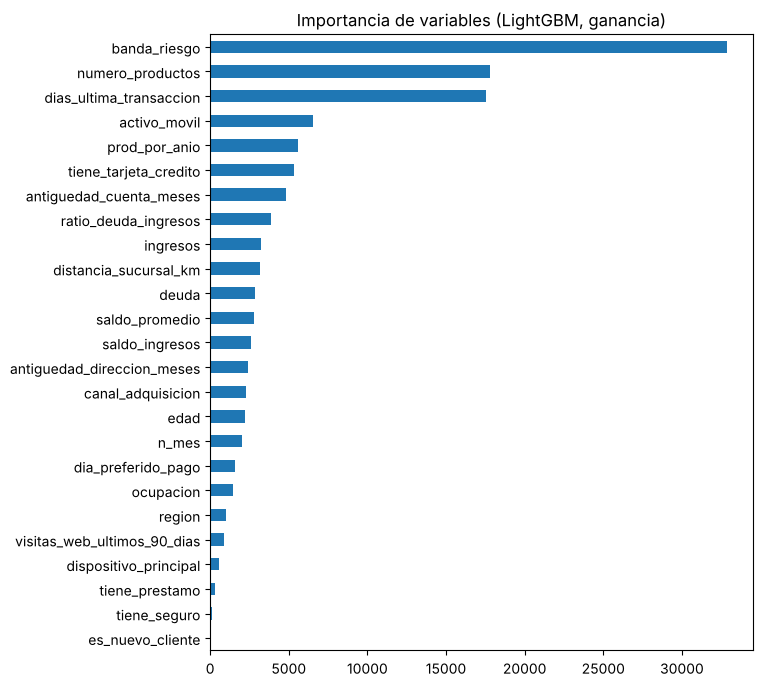

In [17]:
A, _ = preparar_lgb(trn, trn.head(1), F_FE)                     # preparamos todos los datos de ene–nov
m_imp = lgb.LGBMClassifier(**LGB_PARAMS).fit(A, trn.objetivo)   # entrenamos un LightGBM con todo
imp = pd.Series(m_imp.booster_.feature_importance('gain'), F_FE).sort_values()   # importancia de cada variable
imp.plot(kind='barh', figsize=(7, 8), title='Importancia de variables (LightGBM, ganancia)')   # barras horizontales
plt.show()

## 9. Entrenamiento final y archivo de entrega
Ahora sí: entrenamos con **todo enero a noviembre** y predecimos **diciembre**.

In [18]:
a = trn                         # entrenamiento: ene–nov completo
b = df[df.mes == 202612]        # a predecir: diciembre (las filas de test)
# diccionario de 'recetas': cada una entrena su modelo y devuelve probabilidades para diciembre
finales = {'logistica_base': lambda: modelo_logistico(a, b, F_BASE),
           'lgb_base':       lambda: modelo_lgb(a, b, F_BASE),
           'lgb_fe':         lambda: modelo_lgb(a, b, F_FE),
           'cat_fe':         lambda: modelo_cat(a, b, F_FE)}
# si el mejor fue un ensamble, sus componentes; si fue un modelo solo, ese modelo
componentes = {'ens_lgb_cat': ['lgb_fe', 'cat_fe'],
               'ens_todos':   ['logistica_base', 'lgb_fe', 'cat_fe']}.get(MEJOR, [MEJOR])
p_test = {n: finales[n]() for n in componentes}    # ejecuta las recetas necesarias
if len(componentes) == 1:
    pred = p_test[componentes[0]]                   # un solo modelo: usamos su probabilidad directamente
else:
    r = sum(rankdata(p_test[n]) for n in componentes)   # ensamble: suma de rankings
    pred = (r - r.min()) / (r.max() - r.min())          # reescalamos a [0, 1] porque la entrega exige valores entre 0 y 1

entrega = pd.DataFrame({'id_cliente': b.id_cliente.values, 'prediccion': pred})   # tabla final con 2 columnas

# Verificaciones: si alguna falla, el código se detiene con error (mejor detectarlo aquí que en la plataforma)
assert list(entrega.columns) == ['id_cliente', 'prediccion']                    # columnas exactas
assert len(entrega) == len(test) and (entrega.id_cliente.values == test.id_cliente.values).all()   # mismas filas y mismo orden
assert entrega.prediccion.between(0, 1).all() and entrega.prediccion.notna().all()               # entre 0 y 1, sin vacíos
entrega.to_csv('submission.csv', index=False)       # guardamos el CSV; index=False evita una columna extra de números
print('submission.csv guardado con', len(entrega), 'filas usando', MEJOR)
entrega.describe()    # resumen estadístico de las probabilidades (mínimo, promedio, máximo...)

submission.csv guardado con 9900 filas usando lgb_fe


,id_cliente,prediccion
count,9900.000000,9900.000000
mean,17561.905657,0.142241
std,7424.313150,0.061110
min,2.000000,0.020980
25%,12696.500000,0.119147
50%,19704.000000,0.139444
75%,23824.250000,0.159878
max,26467.000000,0.445910


In [19]:
# En Colab, descarga el archivo a tu computadora
try:
    from google.colab import files
    files.download('submission.csv')
except ImportError:
    pass    # fuera de Colab no hace nada

## 10. ¿Qué significan las probabilidades?
Cada número de `prediccion` responde: **«De 100 clientes parecidos a este, ¿cuántos convertirían en diciembre?»**

- `0,30` → de 100 clientes con un perfil así, ~30 convertirían. Es **el doble** del promedio (15%).
- `0,15` → cliente promedio.
- `0,03` → ~3 de cada 100: muy poco probable.

**Importante:** una probabilidad no es un sí o un no. Un cliente con 0,30 lo más probable es que **no** convierta (70%), pero es de los mejores candidatos. Por eso lo útil es el **ranking**: a quién llamar primero.

Comprobémoslo con noviembre, donde sí sabemos qué pasó: ordenamos a los clientes por la probabilidad que el modelo les dio y los partimos en 10 grupos (**deciles**) de igual tamaño.

,clientes,prob_media,conversion_real,conversiones,lift,captura_acum
decil,,,,,,
10,950,0.273,0.294,279.0,1.939,0.194
9,950,0.181,0.158,150.0,1.042,0.298
8,950,0.158,0.175,166.0,1.154,0.413
7,950,0.148,0.167,159.0,1.105,0.524
6,950,0.141,0.166,158.0,1.098,0.634
5,950,0.134,0.147,140.0,0.973,0.731
4,950,0.127,0.146,139.0,0.966,0.828
3,950,0.117,0.140,133.0,0.924,0.920
2,950,0.078,0.065,62.0,0.431,0.963


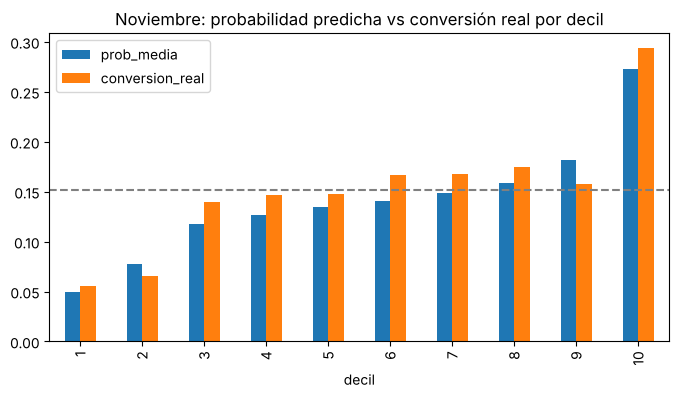

In [20]:
nov = trn[trn.mes == 202611].copy()                 # clientes de noviembre (respuesta conocida)
nov['prob'] = oof['lgb_fe'][202611]                 # probabilidad que el modelo les asignó SIN haber visto noviembre
# qcut parte en 10 grupos de igual tamaño; ranking first evita empates; labels: 10 = los de mayor probabilidad
nov['decil'] = pd.qcut(nov.prob.rank(method='first'), 10, labels=range(1, 11))
dec = nov.groupby('decil', observed=True).agg(clientes=('objetivo', 'size'),
                                              prob_media=('prob', 'mean'),          # lo que el modelo predijo en promedio
                                              conversion_real=('objetivo', 'mean'), # lo que realmente pasó
                                              conversiones=('objetivo', 'sum'))
dec = dec.sort_index(ascending=False)               # decil 10 (los mejores) arriba
dec['lift'] = dec.conversion_real / nov.objetivo.mean()          # cuántas veces mejor que el promedio
dec['captura_acum'] = dec.conversiones.cumsum() / dec.conversiones.sum()   # % de todas las conversiones capturadas hasta ese decil
display(dec.round(3))

ax = dec.sort_index()[['prob_media', 'conversion_real']].plot(kind='bar', figsize=(8, 4),
        title='Noviembre: probabilidad predicha vs conversión real por decil')
ax.axhline(nov.objetivo.mean(), ls='--', c='gray'); plt.show()   # línea gris = tasa promedio

**Cómo leer la tabla:**
- **prob_media vs conversion_real:** si se parecen, las probabilidades están *bien calibradas* (un 0,25 realmente significa ~25%).
- **lift:** el decil 10 convierte X veces más que el promedio. Si contactamos solo a ese 10%, cada llamada rinde X veces más.
- **captura_acum:** qué porcentaje de todos los que convirtieron encontramos contactando solo a los primeros deciles. Si el modelo fuera al azar, el 30% de los clientes capturaría el 30% de las conversiones; con el modelo capturamos más.

**Uso de negocio:** si el banco solo puede llamar a 3.000 de los 9.900 clientes de diciembre, ordena el archivo por `prediccion` de mayor a menor y llama a los primeros 3.000.

Y el **Gini** resume todo esto en un número: 0 = el orden es como lanzar una moneda; 1 = todos los que convierten quedan arriba. Nuestro ~0,25 significa que el modelo ordena claramente mejor que el azar, aunque los datos tienen bastante ruido.

## 11. Próximos pasos para el equipo
Regla: una idea **solo entra si sube el Gini medio** de la validación temporal.
1. Optuna para hiperparámetros.
2. Más variables económicas (riesgo × productos, tramos de edad o ingresos).
3. Promedio de 5 semillas de LightGBM.
4. Dar más peso a los meses recientes (`sample_weight`).
5. Modelo de supervivencia en tiempo discreto.
6. SHAP para explicar predicciones individuales.